In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'  # Mac이면 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

## Step 1. 데이터 로드

In [2]:
# 상권변화지표 (취약상권 도출용)
df_상권 = pd.read_csv(
    '../data/08_상권변화지표/서울시 상권분석서비스(상권변화지표-상권).csv',
    encoding='cp949'
)

# 점포 합본 (순성장률 계산용)
df_점포 = pd.read_csv(
    '../data/점포_합본.csv',
    encoding='utf-8-sig'
)

# 길단위인구 (유동인구용)
df_인구 = pd.read_csv(
    '../data/05_길단위인구/서울시 상권분석서비스(길단위인구-상권).csv',
    encoding='cp949'
)

# 분석 기간 필터링 (2019~2024)
df_상권 = df_상권[df_상권['기준_년분기_코드'] < 20250]
df_인구 = df_인구[df_인구['기준_년분기_코드'] < 20250]

print(f'상권변화지표: {df_상권.shape}')
print(f'점포 합본: {df_점포.shape}')
print(f'길단위인구: {df_인구.shape}')

상권변화지표: (39600, 11)
점포 합본: (1831925, 15)
길단위인구: (39589, 27)


## Step 2. 취약상권 20개 도출
- 상권별 전체 분기 중 '상권축소' 비율 계산
- 80~99% 구간 필터링 (100%는 데이터 적은 상권이라 제외)

In [3]:
# 상권별 전체 분기 수
total = df_상권.groupby('상권_코드_명').size()

# 상권별 상권축소 분기 수
축소 = df_상권[df_상권['상권_변화_지표_명'] == '상권축소'].groupby('상권_코드_명').size()

# 상권축소 비율 계산
축소_비율 = (축소 / total * 100).dropna()

# 80~99% 구간 필터링
취약상권_목록 = 축소_비율[
    (축소_비율 >= 80) & (축소_비율 < 100)
].sort_values(ascending=False)

print(f'취약상권 후보 수: {len(취약상권_목록)}개')
print()
print(취약상권_목록.round(1))

취약상권 후보 수: 125개

상권_코드_명
금천해태공원             95.8
금동어린이공원            95.8
구로보건소              95.8
관악신사시장             95.8
경기대학교              95.8
                   ... 
서울금융고등학교           83.3
은평구청               83.3
왕십리역 9번            83.3
투구봉어린이공원           83.3
천호지구대(천호동자전거거리)    83.3
Length: 125, dtype: float64


In [4]:
# 8분기 이상 등장한 상권만 필터링
유효상권 = total[total >= 8].index
축소_비율_필터 = 축소_비율[축소_비율.index.isin(유효상권)]

# 80~99% 구간 필터링 + 상위 20개
취약상권_목록 = 축소_비율_필터[
    (축소_비율_필터 >= 80) & (축소_비율_필터 < 100)
].sort_values(ascending=False).head(20)  # 상위 20개만

print(f'취약상권 수: {len(취약상권_목록)}개')
print()
print(취약상권_목록.round(1))

취약상권 수: 20개

상권_코드_명
금천해태공원           95.8
금동어린이공원          95.8
구로보건소            95.8
관악신사시장           95.8
경기대학교            95.8
난우중학교            95.8
망우역 1번           95.8
디지털단지오거리         95.8
방배동카페골목          95.8
보문역 4번           95.8
돌곶이시장(석관황금시장)    95.8
방학동도깨비시장         95.8
성북구청             95.8
연신내우체국           95.8
응암1동주민센터         95.8
응봉산              95.8
중곡3동주민센터         95.8
솔숲어린이공원          95.8
송천초등학교           95.8
신풍역 1번           95.8
dtype: float64


## 취약상권 후보 도출 과정
- 상권별 전체 분기 중 상권축소 비율 계산
- 100% 상권 제외 → 데이터 편향 가능성 있음
- 80~99% 구간 상위 20개 추출
- 결과: 24분기 중 23분기가 상권축소인 상권 20개 (95.8%)

## 취약상권 후보 해석
- 골목상권 14개 (70%): 구조적으로 가장 취약한 유형
- 전통시장 3개 (15%): 오래된 시장 만성 축소 중
- 발달상권 3개 (15%): 유동인구 감소 또는 상권 이동 가능성

## 최종 인사이트
- 서울 상권은 전반적으로 코로나 회복 완료
- 단, 골목상권·일부 전통시장은 코로나와 무관하게 만성적 축소 중

## Step 3. 취약상권 20개에 순성장률 연결
- 소희님 점포 데이터로 순성장률 계산
- 순성장률 = 개업률 - 폐업률

In [5]:
# 연도 컬럼 추가
if '연도' not in df_점포.columns:
    df_점포['연도'] = df_점포['기준_년분기_코드'].astype(str).str[:4].astype(int)

# 상권별 순성장률 계산
df_점포_집계 = df_점포.groupby(['상권_코드', '상권_코드_명']).agg(
    총점포수=('점포_수', 'sum'),
    총개업수=('개업_점포_수', 'sum'),
    총폐업수=('폐업_점포_수', 'sum')
).reset_index()

df_점포_집계['개업률'] = (df_점포_집계['총개업수'] / df_점포_집계['총점포수'] * 100).round(2)
df_점포_집계['폐업률'] = (df_점포_집계['총폐업수'] / df_점포_집계['총점포수'] * 100).round(2)
df_점포_집계['순성장률'] = (df_점포_집계['개업률'] - df_점포_집계['폐업률']).round(2)

# 취약상권 20개만 필터링 (순성장률)
취약_순성장 = df_점포_집계[
    df_점포_집계['상권_코드_명'].isin(취약상권_목록.index)
][['상권_코드_명', '개업률', '폐업률', '순성장률']]

# 취약상권 유형 정보
취약_df = df_상권[df_상권['상권_코드_명'].isin(취약상권_목록.index)][
    ['상권_코드_명', '상권_구분_코드_명']
].drop_duplicates()

print(f'순성장률: {취약_순성장.shape}')
print(f'유형 분포: {취약_df["상권_구분_코드_명"].value_counts().to_dict()}')

순성장률: (20, 4)
유형 분포: {'골목상권': 14, '전통시장': 3, '발달상권': 3}


## Step 3. 인사이트 - 취약상권 순성장률

### 핵심 발견
- 취약상권 20개 중 순성장률 플러스(+) 상권 다수 존재
- 순성장률 플러스 = 개업이 폐업보다 많음
- 상권축소 지표와 모순처럼 보이지만 다른 걸 측정하는 것

### 해석
- 순성장률(점포 수 기준): 새 가게가 들어오는 속도
- 상권변화지표(운영/폐업 개월 기준): 가게들이 오래 버티는지 여부
- 순성장률 높아도 상권축소 = 새 가게는 들어오지만 빨리 폐업하는 구조
  → 회전율 높은 불안정한 상권

### 비즈니스 시사점
- 순성장률만 보고 창업하면 위험
- 상권변화지표(운영 개월)까지 함께 봐야 진짜 안정적인 상권인지 알 수 있음

## Step 4. 취약상권 20개에 유동인구 연결
- 취약상권의 유동인구 추이 확인
- 유동인구가 줄고 있는지 / 원래 적은지 확인

In [6]:
# 연도 컬럼 추가
df_인구['연도'] = df_인구['기준_년분기_코드'].astype(str).str[:4].astype(int)

# 연도 + 상권 기준 평균 유동인구
df_인구_집계 = df_인구.groupby(['연도', '상권_코드', '상권_코드_명']).agg(
    평균_유동인구=('총_유동인구_수', 'mean')
).reset_index()

# 취약상권 20개만 필터링
취약_인구 = df_인구_집계[
    df_인구_집계['상권_코드_명'].isin(취약상권_목록.index)
]

print(f'취약상권 유동인구 데이터: {취약_인구.shape}')
print(f'상권 수: {취약_인구["상권_코드_명"].nunique()}개')
취약_인구.head()

취약상권 유동인구 데이터: (120, 4)
상권 수: 20개


,연도,상권_코드,상권_코드_명,평균_유동인구
110,2019,3110105,금동어린이공원,904437.75
118,2019,3110113,응봉산,240129.50
163,2019,3110158,중곡3동주민센터,2384223.75
270,2019,3110265,망우역 1번,448079.25
303,2019,3110298,솔숲어린이공원,243627.25


In [7]:
# 취약상권 20개 연도별 평균 유동인구
취약_평균 = 취약_인구.groupby('연도')['평균_유동인구'].mean().reset_index()
취약_평균.columns = ['연도', '취약상권_평균']

# 전체 상권 연도별 평균 유동인구
전체_평균 = df_인구_집계.groupby('연도')['평균_유동인구'].mean().reset_index()
전체_평균.columns = ['연도', '전체상권_평균']

# 합치기
비교 = pd.merge(취약_평균, 전체_평균, on='연도')

print(비교.round(0).to_string(index=False))

  연도  취약상권_평균  전체상권_평균
2019 934339.0 881564.0
2020 944814.0 857759.0
2021 940647.0 830834.0
2022 956389.0 834681.0
2023 946759.0 828491.0
2024 949655.0 818447.0


## Step 4. 인사이트 - 취약상권 유동인구

### 핵심 발견
- 취약상권 평균 유동인구가 전체 상권 평균보다 높음
- 예상과 반대 결과 → 유동인구 많아도 상권 취약할 수 있음

### 해석
- 취약상권 20개 대부분: 학교, 공원, 주민센터, 어린이공원 주변
- 유동인구는 많지만 소비 목적 방문이 아닌 통행 인구가 대부분
- 유동인구의 "양"이 아닌 "질"의 문제

### 비즈니스 시사점
- "취약상권의 문제는 유동인구 부족이 아니라 소비 전환율이 낮은 통행 인구 중심 구조다"
- 유동인구 수치만 보고 창업 입지 결정하면 위험
- 유동인구의 목적(소비/통행)까지 분석해야 정확한 상권 평가 가능

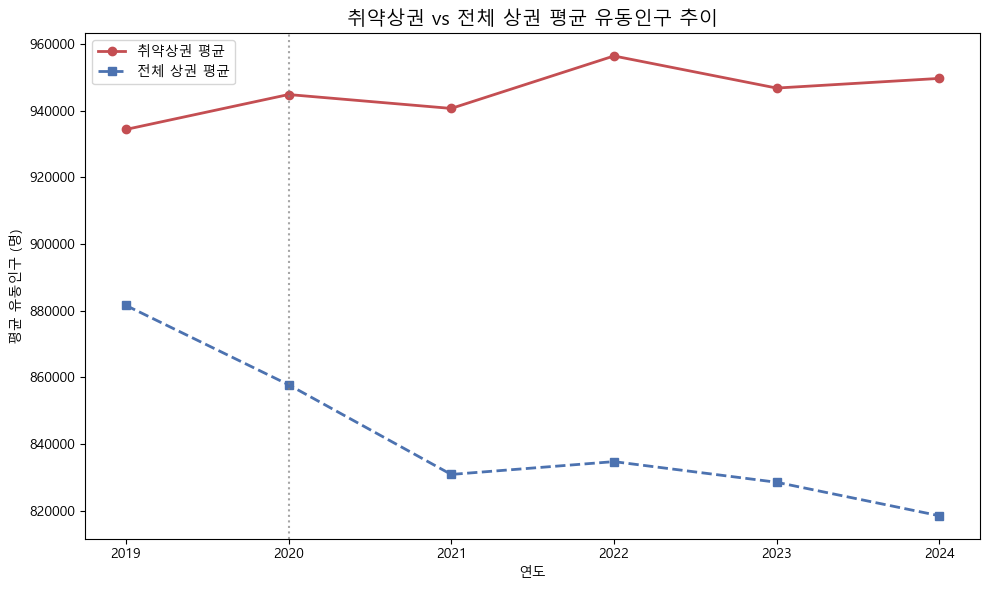

In [8]:
# 취약상권 vs 전체 상권 유동인구 추이 비교
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(비교['연도'], 비교['취약상권_평균'],
        marker='o', color='#C44E52', linewidth=2, label='취약상권 평균')
ax.plot(비교['연도'], 비교['전체상권_평균'],
        marker='s', color='#4C72B0', linewidth=2, linestyle='--', label='전체 상권 평균')

ax.set_title('취약상권 vs 전체 상권 평균 유동인구 추이', fontsize=14)
ax.set_xlabel('연도')
ax.set_ylabel('평균 유동인구 (명)')
ax.set_xticks([2019, 2020, 2021, 2022, 2023, 2024])
ax.legend()
ax.axvline(x=2020, color='gray', linestyle=':', alpha=0.7, label='코로나')
plt.tight_layout()
plt.show()

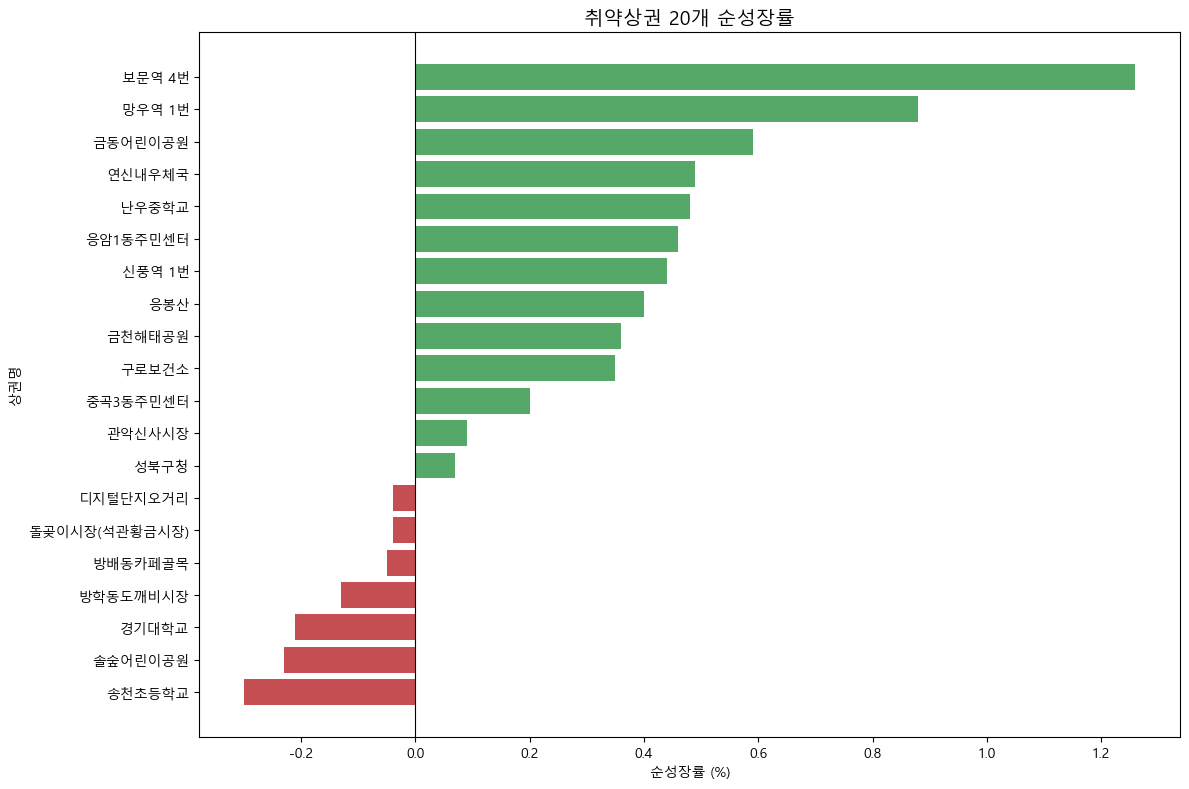

In [9]:
# 취약상권 20개 순성장률 막대그래프
취약_순성장_정렬 = 취약_순성장.sort_values('순성장률')

fig, ax = plt.subplots(figsize=(12, 8))

# 순성장률 플러스/마이너스 색상 구분
colors = ['#C44E52' if x < 0 else '#55A868' for x in 취약_순성장_정렬['순성장률']]

ax.barh(취약_순성장_정렬['상권_코드_명'], 취약_순성장_정렬['순성장률'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)  # 0 기준선

ax.set_title('취약상권 20개 순성장률', fontsize=14)
ax.set_xlabel('순성장률 (%)')
ax.set_ylabel('상권명')
plt.tight_layout()
plt.show()

## Step 4. 추가 인사이트 - 순성장률 패턴

### 핵심 발견
- 취약상권 중 순성장률 마이너스: 시장, 카페골목, 학교, 디지털단지 등 실제 상업 기능 상권
- 취약상권 중 순성장률 플러스: 공원, 주민센터, 우체국 주변 통행 인구 중심 상권

### 해석
- 통행 인구 중심 상권: 개폐업 자체가 적어서 순성장률 플러스처럼 보임
- 실제 상업 기능 상권: 폐업이 개업보다 많아 순성장률 마이너스 → 더 위험
- 취약상권 중에서도 실제 상업 기능이 있는 곳이 더 심각한 상태

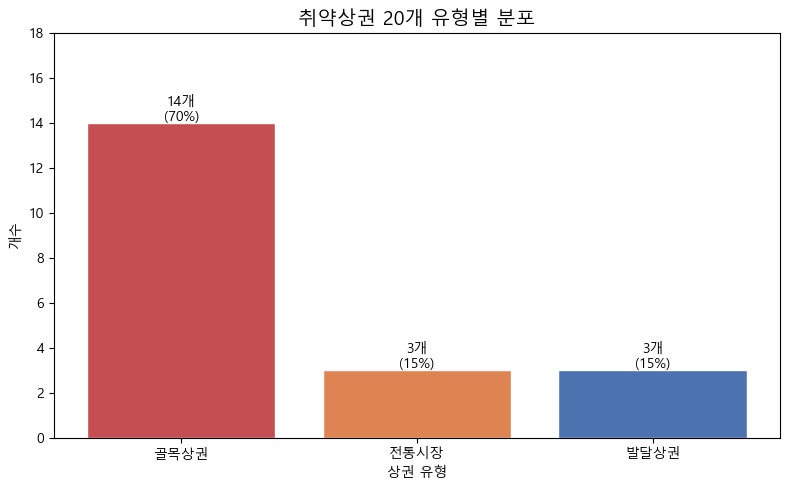

In [10]:
# 취약상권 유형별 분포 막대그래프
fig, ax = plt.subplots(figsize=(8, 5))

유형별_수 = 취약_df['상권_구분_코드_명'].value_counts()

colors = ['#C44E52', '#DD8452', '#4C72B0']
bars = ax.bar(유형별_수.index, 유형별_수.values, color=colors, edgecolor='white')

# 막대 위에 개수 표시
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{int(bar.get_height())}개\n({int(bar.get_height())/20*100:.0f}%)',
            ha='center', fontsize=10)

ax.set_title('취약상권 20개 유형별 분포', fontsize=14)
ax.set_xlabel('상권 유형')
ax.set_ylabel('개수')
ax.set_ylim(0, 18)
plt.tight_layout()
plt.show()

## Step 5. 최종 인사이트 종합

### 취약상권 20개 특징 요약
1. 상권축소 비율 95.8% (24분기 중 23분기 축소)
2. 골목상권 14개(70%) 압도적 → 소자본 창업 중심, 경기 충격에 취약
3. 유동인구는 전체 평균보다 높음 → 유동인구 부족이 문제가 아님
4. 순성장률 마이너스 상권 = 실제 상업 기능 있는 곳 → 더 심각

### 핵심 결론
- 취약상권의 문제는 유동인구 부족이 아니라 소비 전환율이 낮은 구조
- 순성장률만 보고 창업하면 위험 → 상권변화지표까지 함께 봐야 함
- 골목상권 취약성은 구조적 문제 → 정책적 지원 필요

### 비즈니스 시사점
- 창업 입지 선정 시 유동인구 수치 + 소비 목적 여부 + 상권변화지표 3가지 동시 확인
- 취약상권 정책 우선순위: 실제 상업 기능 있는 마이너스 순성장 상권 집중 지원

In [11]:
# ============================================
# 보충 EDA ① - 취약상권 vs 건강상권 순성장률 비교
# 목적: "순성장률 플러스 ≠ 상권 회복" 수치로 뒷받침
# ============================================

# 건강상권 = 상권축소 비율 낮은 상위 20개
건강상권_목록 = 축소_비율[
    축소_비율.index.isin(유효상권)
].sort_values(ascending=True).head(20)

print(f'건강상권 수: {len(건강상권_목록)}개')
print()
print(건강상권_목록.round(1))

건강상권 수: 20개

상권_코드_명
개화산역 1번          4.2
충정로역 3번          4.2
명일전통시장           4.2
구로구청             4.2
강서구다솔마을          4.2
강북문화정보도서관        4.2
문현중학교(장지역 1번)    4.2
목동역 5번           4.2
숭실대입구역 1번        4.2
양천향교역 2번         4.2
언남고등학교           4.2
구역삼세무서           4.2
구산역 1번           4.2
구세군강북종합사회복지관     4.2
중곡역 3번           4.2
중화역 1번           4.2
아차산역 1번          4.2
양평역 2번           4.2
응암오거리상점가         4.2
백학시장             4.2
dtype: float64


In [12]:
# ============================================
# 건강상권 순성장률 계산
# ============================================

# 건강상권 점포 데이터 필터링
건강_순성장 = df_점포_집계[
    df_점포_집계['상권_코드_명'].isin(건강상권_목록.index)
][['상권_코드_명', '순성장률']].copy()

# 취약상권 순성장률 (기존 변수)
취약_평균_순성장 = 취약_순성장['순성장률'].mean()
건강_평균_순성장 = 건강_순성장['순성장률'].mean()

# 비교표 출력
print('=== 순성장률 비교 ===')
print(f'취약상권 평균 순성장률: {취약_평균_순성장:.2f}%')
print(f'건강상권 평균 순성장률: {건강_평균_순성장:.2f}%')
print()

# 유동인구 비교
건강_인구 = df_인구_집계[
    df_인구_집계['상권_코드_명'].isin(건강상권_목록.index)
]
건강_평균_유동 = 건강_인구['평균_유동인구'].mean()
취약_평균_유동 = 취약_인구['평균_유동인구'].mean()

print('=== 유동인구 비교 ===')
print(f'취약상권 평균 유동인구: {취약_평균_유동:,.0f}명')
print(f'건강상권 평균 유동인구: {건강_평균_유동:,.0f}명')

=== 순성장률 비교 ===
취약상권 평균 순성장률: 0.25%
건강상권 평균 순성장률: 0.50%

=== 유동인구 비교 ===
취약상권 평균 유동인구: 945,434명
건강상권 평균 유동인구: 797,068명


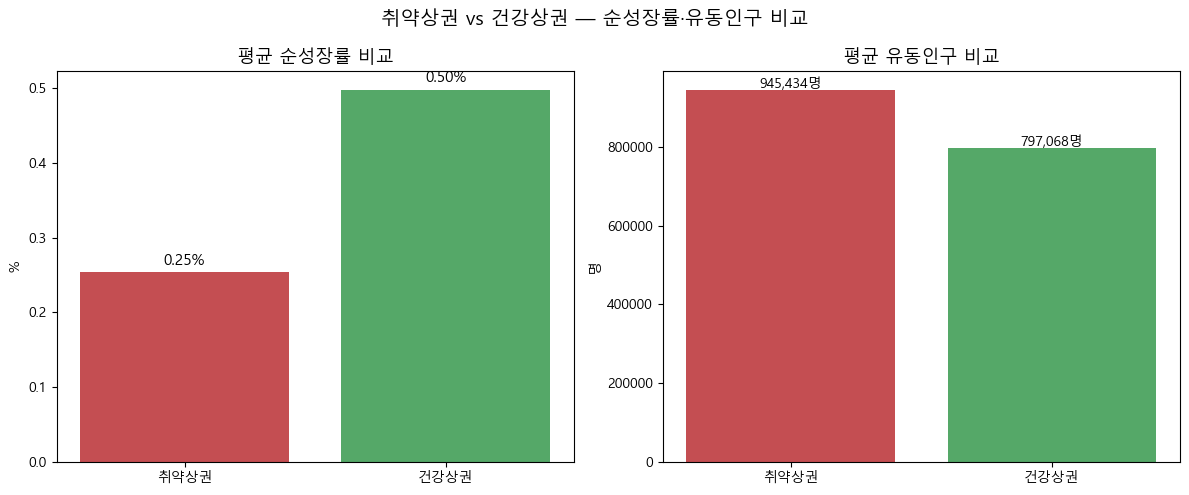

In [13]:
# ============================================
# 취약 vs 건강상권 비교 막대그래프
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

categories = ['취약상권', '건강상권']
colors = ['#C44E52', '#55A868']

# 순성장률 비교
axes[0].bar(categories, [취약_평균_순성장, 건강_평균_순성장], color=colors)
axes[0].set_title('평균 순성장률 비교', fontsize=13)
axes[0].set_ylabel('%')
for i, v in enumerate([취약_평균_순성장, 건강_평균_순성장]):
    axes[0].text(i, v + 0.01, f'{v:.2f}%', ha='center', fontsize=11)

# 유동인구 비교
axes[1].bar(categories, [취약_평균_유동, 건강_평균_유동], color=colors)
axes[1].set_title('평균 유동인구 비교', fontsize=13)
axes[1].set_ylabel('명')
for i, v in enumerate([취약_평균_유동, 건강_평균_유동]):
    axes[1].text(i, v + 5000, f'{v:,.0f}명', ha='center', fontsize=10)

plt.suptitle('취약상권 vs 건강상권 — 순성장률·유동인구 비교', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
# ============================================
# 순성장률 vs 상권축소 비율 비교표
# ============================================

summary = pd.DataFrame({
    '구분': ['취약상권 20개', '건강상권 20개'],
    '평균 순성장률(%)': [취약_평균_순성장.round(2), 건강_평균_순성장.round(2)],
    '상권축소 비율(%)': [95.8, 4.2]
})

print(summary.to_string(index=False))

      구분  평균 순성장률(%)  상권축소 비율(%)
취약상권 20개        0.25        95.8
건강상권 20개        0.50         4.2
